In [17]:
# numpy and pandas for data manipulation
import numpy as np
import pandas as pd 
from sklearn.linear_model import LogisticRegression,RidgeClassifier, SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.decomposition import KernelPCA
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
import category_encoders as ce


from scipy.stats import randint, uniform
from scipy.stats import loguniform


from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    MinMaxScaler
)

from sklearn.impute import SimpleImputer

from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    f_classif
)

from sklearn.svm import SVC



from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    log_loss,
    roc_auc_score,
    f1_score,
    balanced_accuracy_score
)


from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer, KNNImputer

from sklearn.pipeline import FunctionTransformer
from sklearn.preprocessing import PowerTransformer, RobustScaler

from sklearn.base import clone
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.decomposition import KernelPCA
from imblearn.over_sampling import SMOTE

from sklearn.preprocessing import LabelEncoder

# File system manangement
import os

# Suppress warnings 
import warnings
warnings.filterwarnings('ignore')

# matplotlib and seaborn for plotting
import matplotlib.pyplot as plt
import seaborn as sns



from sklearnex import patch_sklearn
patch_sklearn()  # patches scikit-learn algorithms
# from sklearnex import unpatch_sklearn
# unpatch_sklearn()



# ------------------- IMPORT SRC ------------------------------------
# src is the parent folder of notebooks, so we need to add it to sys.path to import config and utils
import sys
notebook_dir = os.getcwd() 

# Parent folder of src
project_root = os.path.abspath(os.path.join(notebook_dir, "..")) 
sys.path.append(project_root)

print("sys.path contains:", sys.path[-1])

from src.config import Config as Config  
from src.data_loader import load_data, prepare_data

cfg = Config

KAGGLE_EVAL = cfg.KAGGLE_EVAL
RANDOM_STATE = cfg.RANDOM_STATE
TASK = cfg.TASK
USE_POSTPROCESSING = cfg.USE_POSTPROCESSING
TARGET = cfg.TARGET
ID = cfg.ID
SUB_PATH = cfg.SUB_PATH
SUBMIT_PROBABILITIES = cfg.SUBMIT_PROBABILITIES

# -------------------------------------------------------


# this notebook
from src.optuna_utils import run_optuna
from src.training_utils import train_lgbm_final
from src.evaluation_utils import evaluate_model, evaluate_metric
from src.visualization_utils import (
    plot_feature_importance,
    plot_learning_curve,
    shap_summary
)
from sklearn.metrics import accuracy_score,roc_auc_score, log_loss

from src.postprocessing_utils import optimize_postprocessing, apply_postprocessing


# -------------------------------
# Load Data
# -------------------------------
X_train, X_test, y_train, y_test = load_data("raw") #
# Prepare
X_train, X_test, y_train_numeric, y_test_numeric, test_ids, num_classes, int_to_label = prepare_data(
    X_train, X_test, y_train, y_test, target=cfg.TARGET, drop_id=True # ,label_map = {"A": 1, "B": 0, "C": 2}
)

# Ensure y is numpy array
y_train_numeric = np.array(y_train_numeric)
y_test_numeric = np.array(y_test_numeric) if y_test_numeric is not None else None


cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

sys.path contains: /home/ismail/x42
Number of classes: 663
X_train shape: (1460, 79)
X_test shape: (1459, 79)
y_train shape: (1460,)
y_test labels are not available
Test IDs available: 1459


Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


for regression try y_binned = converting continuous target into categories so stratified splitting works properly.

In [3]:

y_train[TARGET] = np.log1p(y_train[TARGET])



# 10 bins is usually the "sweet spot" for datasets of 1k-100k rows
# y_binned = pd.qcut(
#     y_train[TARGET].rank(method='first'), 
#     q=10, 
#     labels=False
# )
# y_binned

In [18]:
# ======================
# 1. SETUP
# ======================
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import skew
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline


# ======================
# 2. SAFE MERGE (KEEP TRACK OF ROWS)
# ======================
n_train = len(X_train)

X_train = X_train.copy().reset_index(drop=True)
y_train = y_train.copy().reset_index(drop=True)
X_test = X_test.copy().reset_index(drop=True)

train = pd.concat([X_train, y_train], axis=1)

# remove outliers
train = train.drop(
    train[(train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000)].index
).reset_index(drop=True)


# ======================
# 3. SPLIT BACK SAFE BASE
# ======================
X = train.drop(columns=['SalePrice'])
y = train['SalePrice']


# ======================
# 4. COMBINE (ONLY FEATURES)
# ======================
full = pd.concat([X, X_test], axis=0, ignore_index=True)

full = full.drop(columns=['Id'], errors='ignore')


# ======================
# 5. MISSING VALUES
# ======================
full['LotAreaCut'] = pd.qcut(full['LotArea'], 10, duplicates='drop')

full['LotFrontage'] = full.groupby(['LotAreaCut','Neighborhood'])['LotFrontage'] \
    .transform(lambda x: x.fillna(x.median()))

full['LotFrontage'] = full.groupby('LotAreaCut')['LotFrontage'] \
    .transform(lambda x: x.fillna(x.median()))

num_fill_zero = [
    "MasVnrArea","BsmtUnfSF","TotalBsmtSF","GarageCars",
    "BsmtFinSF2","BsmtFinSF1","GarageArea"
]
full[num_fill_zero] = full[num_fill_zero].fillna(0)

cat_fill_none = [
    "PoolQC","MiscFeature","Alley","Fence","FireplaceQu",
    "GarageQual","GarageCond","GarageFinish","GarageYrBlt",
    "GarageType","BsmtExposure","BsmtCond","BsmtQual",
    "BsmtFinType2","BsmtFinType1","MasVnrType"
]
full[cat_fill_none] = full[cat_fill_none].fillna("None")

cat_fill_mode = [
    "MSZoning","BsmtFullBath","BsmtHalfBath","Utilities",
    "Functional","Electrical","KitchenQual","SaleType",
    "Exterior1st","Exterior2nd"
]

for c in cat_fill_mode:
    full[c] = full[c].fillna(full[c].mode()[0])


# ======================
# 6. TYPE FIX
# ======================
NumStr = [
    "MSSubClass","BsmtFullBath","BsmtHalfBath","HalfBath",
    "BedroomAbvGr","KitchenAbvGr","MoSold","YrSold",
    "YearBuilt","YearRemodAdd","LowQualFinSF","GarageYrBlt"
]

full[NumStr] = full[NumStr].astype(str)


# ======================
# 7. SAFE ORDINAL MAPPING
# ======================
def map_values(df):
    df = df.copy()

    df["oMSSubClass"] = df.MSSubClass.map({
        '180':1,'30':2,'45':2,'190':3,'50':3,'90':3,
        '85':4,'40':4,'160':4,'70':5,'20':5,'75':5,
        '80':5,'150':5,'120':6,'60':6
    })

    df["oMSZoning"] = df.MSZoning.map({
        'C (all)':1,'RH':2,'RM':2,'RL':3,'FV':4
    })

    df["oNeighborhood"] = df.Neighborhood.map({
        'MeadowV':1,'IDOTRR':2,'BrDale':2,'OldTown':3,
        'Edwards':3,'BrkSide':3,'Sawyer':4,'Blueste':4,
        'SWISU':4,'NAmes':4,'NPkVill':5,'Mitchel':5,
        'SawyerW':6,'Gilbert':6,'NWAmes':6,'Blmngtn':7,
        'CollgCr':7,'ClearCr':7,'Crawfor':7,'Veenker':8,
        'Somerst':8,'Timber':8,'StoneBr':9,
        'NoRidge':10,'NridgHt':10
    })

    return df


full = map_values(full)


# IMPORTANT: drop only AFTER mapping
full = full.drop(columns=["LotAreaCut"], errors='ignore')


# ======================
# 8. PIPELINE (NO DATA LEAKAGE)
# ======================
class AddFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, additional=2):
        self.additional = additional

    def fit(self, X, y=None): return self

    def transform(self, X):
        X = X.copy()

        X["TotalHouse"] = X["TotalBsmtSF"] + X["1stFlrSF"] + X["2ndFlrSF"]
        X["TotalArea"] = X["TotalHouse"] + X["GarageArea"]

        if self.additional == 2:
            X["Rooms"] = X["FullBath"] + X["TotRmsAbvGrd"]
            X["Bsmt"] = X["BsmtFinSF1"] + X["BsmtFinSF2"] + X["BsmtUnfSF"]

        return X


class SkewFix(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=1):
        self.threshold = threshold

    def fit(self, X, y=None): return self

    def transform(self, X):
        X = X.copy()
        num = X.select_dtypes(include=np.number)

        sk = num.apply(skew)
        cols = sk[abs(sk) >= self.threshold].index

        X[cols] = np.log1p(X[cols])
        return X


class Dummies(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None): return self

    def transform(self, X):
        return pd.get_dummies(X)


pipeline = Pipeline([
    ('features', AddFeatures(2)),
    ('skew', SkewFix(1)),
    ('dummies', Dummies())
])


# ======================
# 9. APPLY PIPELINE
# ======================
full_processed = pipeline.fit_transform(full)


# ======================
# 10. CRITICAL FIX: ALIGN COLUMNS
# ======================
X_full = full_processed.iloc[:len(X)]
X_test_full = full_processed.iloc[len(X):]

# 🔥 FORCE SAME COLUMNS (THIS FIXES YOUR ERROR)
X_test_full = X_test_full.reindex(columns=X_full.columns, fill_value=0)


# ======================
# 11. SCALE
# ======================
scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_full)
X_test_scaled = scaler.transform(X_test_full)


# ======================
# 12. FINAL SAFE OUTPUT
# ======================
X_train = pd.DataFrame(X_train_scaled, columns=X_full.columns).reset_index(drop=True)
X_test = pd.DataFrame(X_test_scaled, columns=X_full.columns).reset_index(drop=True)

y_train = np.log1p(y).reset_index(drop=True).fillna(np.log1p(y).mean())

y_train_numeric = y_train.copy()

In [19]:
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [ ]:
# X_train.to_csv('../data/X_train_encoded.csv', index=False)
# X_test.to_csv('../data/X_test_encoded.csv', index=False)
# y_train.to_csv('../data/y_train.csv', index=False)


In [21]:
y_train

0       12.247699
1       12.109016
2       12.317171
3       11.849405
4       12.429220
          ...    
1453    12.072547
1454    12.254868
1455    12.493133
1456    11.864469
1457    11.901590
Name: SalePrice, Length: 1458, dtype: float64

In [ ]:
from src.data_splitter import DataSplitter


# ⚠️ If you don’t set folds_path, it will generate new random splits every time you call split().
splitter = DataSplitter(
    method="stratified_kfold",
    # method="repeated_stratified",
    n_splits=5,
    random_state=42,
    # n_repeats=10,
    # random_states=[42, 1337],  # multi-seed CV
    folds_path="data/folds.npy"
)

folds = list(splitter.split(X_train, y_train_numeric, reuse_folds=True, verbose=True))

✅ Generated 5 folds for current dataset
--- Splitting data ---
Method: kfold
Number of splits: 5
Random seeds: [42]
Dataset size: 1458
Total folds: 5

Fold 0: Train size=1166, Val size=292
Fold 1: Train size=1166, Val size=292
Fold 2: Train size=1166, Val size=292
Fold 3: Train size=1167, Val size=291
Fold 4: Train size=1167, Val size=291


**Special functions for pipline**

In [117]:


# from sklearn.base import BaseEstimator, TransformerMixin


# def svd_rounder(x):
    
#     x_copy = x.copy()
#     for col in [column for column in list(x) if 'SVD' in column]:
#         x_copy[col] = (x_copy[col] * 1e18).astype(np.int64)
        
#     return x_copy

# SVDRounder = FunctionTransformer(svd_rounder)




# class FeatureDropper(BaseEstimator, TransformerMixin):
    
#     def __init__(self, cols):
#         self.cols = cols
        
#     def fit(self, x, y):
#         return self
    
#     def transform(self, x):
#         return x.drop(self.cols, axis = 1)

# class Categorizer(BaseEstimator, TransformerMixin):
    
#     def __init__(self, cols : list):
#         self.cols = cols
        
#     def fit(self, x, y):
#         return self
    
#     def transform(self, x):
#         return x.astype({cat : 'category' for cat in self.cols})

# class Vectorizer(BaseEstimator, TransformerMixin):
    
#     def __init__(self, max_features = 1000, cols = ['Surname'], n_components = 3):
#         self.max_features = max_features
#         self.cols = cols
#         self.n_components = n_components
        
#     def fit(self, x, y):
#         self.vectorizer_dict = {}
#         self.decomposer_dict = {}
        
#         for col in self.cols:
#             self.vectorizer_dict[col] = TfidfVectorizer(max_features = self.max_features).fit(x[col].astype(str), y)
#             self.decomposer_dict[col] = TruncatedSVD(random_state = config.SEED, n_components = self.n_components).fit(
#                 self.vectorizer_dict[col].transform(x[col].astype(str)), y
#             )
        
#         return self
    
#     def transform(self, x):
#         vectorized = {}
        
#         for col in self.cols:
#             vectorized[col] = self.vectorizer_dict[col].transform(x[col].astype(str))
#             vectorized[col] = self.decomposer_dict[col].transform(vectorized[col])
        
#         vectorized_df = pd.concat([pd.DataFrame(vectorized[col]).rename({
#             f'truncatedsvd{i}' : f'{col}SVD{i}' for i in range(self.n_components)
#         }, axis = 1) for col in self.cols], axis = 1)
        
#         return pd.concat([x.reset_index(drop = True), vectorized_df], axis = 1)


In [23]:


from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor





# Numeric Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
class OutlierCapper(BaseEstimator, TransformerMixin):
    def __init__(self, factor=1.5):
        self.factor = factor
        self.caps_ = {}

    def fit(self, X, y=None):
        # handle both DataFrame and array
        if isinstance(X, np.ndarray):
            X = pd.DataFrame(X)
        for i, col in enumerate(X.columns):
            Q1 = X[col].quantile(0.25)
            Q3 = X[col].quantile(0.75)
            IQR = Q3 - Q1
            self.caps_[i] = (Q1 - self.factor*IQR, Q3 + self.factor*IQR)  # store by index
        return self

    def transform(self, X):
        if isinstance(X, np.ndarray):
            X = pd.DataFrame(X)
        X = X.copy()
        for i, col in enumerate(X.columns):
            lower, upper = self.caps_[i]
            X[col] = X[col].clip(lower, upper)
        return X.values  # return as array for compatibility


cap_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # Optional, only if you have NaNs
    ('cap', OutlierCapper(factor=1.5))
])





# log1p pipeline
log_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('log1p', FunctionTransformer(np.log1p, validate=True)),
    ('cap', OutlierCapper(factor=1.5)),
    ('scaler', MinMaxScaler()),
    ('standard', StandardScaler()) 
])

yj_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('yeojohnson', PowerTransformer(method='yeo-johnson', standardize=False)),
    ('cap', OutlierCapper(factor=1.5)),
    ('scaler', MinMaxScaler()),  # optional if needed
    ('standard', StandardScaler()) 

])

log_cols = []
yj_cols = []
cap_cols = []

other_numeric_cols = [col for col in num_cols if col not in yj_cols]


other_num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
     # ('imputer', KNNImputer(n_neighbors=5, weights='distance')),
    # ('imputer', IterativeImputer(
    #     estimator=RandomForestRegressor(n_estimators=100, random_state=42),
    #     max_iter=10,
    #     random_state=42
    # )),
    ('scaler', MinMaxScaler()),
    ('standard', StandardScaler())
])



# Categorical Pipeline
target_encode_cols = []  # replace with your chosen cols
ord_cols = []
onehot_cols = [c for c in cat_cols if c not in target_encode_cols]


# Target encoding pipeline
target_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('target_encoder', ce.SumEncoder()) # CatBoostEncoder, MEstimateEncoder
])



# One-hot encoding pipeline
onehot_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='if_binary', handle_unknown='ignore', sparse_output=True))
])





ordinal_encoder = OrdinalEncoder(categories=[])

ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=[]))
])






preprocessor = ColumnTransformer(
    transformers=[
        #('log_num', log_pipeline, log_cols),
        # ('yj_num', yj_pipeline, yj_cols),#
        # ('cap_only', cap_pipeline, cap_cols),   # <- new name here
        # ('num', other_num_pipeline, num_cols),
        # ('cap_after', cap_pipeline, ['weekly_exercise_min', 'trig_level', 'bp_diastolic']),
        
        
        # Categorical pipelines
        # ('ordinal', ordinal_pipeline, ord_cols),  
        #('target', target_pipeline, target_encode_cols),
        ('onehot', onehot_pipeline, cat_cols) # onehot_cols
    ],
    remainder='passthrough'
)


# Remove near-constant features
variance_filter = VarianceThreshold(threshold=0.01)


# Statistical feature selectio
feature_selector = SelectKBest(
    score_func=f_classif,
    k=300    # tuneable
)


# Full Pipline


def build_pipeline(model):
    """
    Wraps preprocessing + model in a single pipeline
    """
    pipeline = Pipeline([
        ('preprocess', preprocessor),
        #('variance_filter', variance_filter),
        # ('smote', SMOTE(sampling_strategy="not majority", random_state=42)),
        # ('feature_selection', feature_selector),
        # ('poly', PolynomialFeatures(degree=2, include_bias=False)), 
        ('model', model),

    ])
    return pipeline


# Optuna

In [24]:
import gc
import optuna
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    log_loss,
    mean_squared_error,
    roc_auc_score,
    f1_score,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns


def train_and_evaluate_optuna_train_metrics(
    X_train,
    y_train,
    model_dict,
    folds,
    cfg=cfg,
    n_trials=20,
    plot_confusion=True
):

    models = {}
    summary_list = []
    studies = {}

    task = cfg.TASK.lower()
    num_classes = len(np.unique(y_train))

    is_regression = task == "regression"
    is_binary = task == "binary"
    is_multiclass = task == "multiclass"

    for name, model_cfg in model_dict.items():
        print(f"\n=== Training {name} with Optuna ===")

        pipeline_template = build_pipeline(model_cfg["model"])
        param_space = model_cfg["params"]

        def objective(trial):

            # params = {
            #     k.split("__")[-1]: (v(trial) if callable(v) else v)
            #     for k, v in param_space.items()
            # }

            params = {}
            for k, v in param_space.items():
                new_key = k.replace("model__", "") 
                val = v(trial) if callable(v) else v
                
                # Only skip if we explicitly returned the "drop" flag
                if val != "drop":  
                    params[new_key] = val

            fold_scores = []

            current_oof = np.zeros((len(X_train), num_classes)) if is_multiclass else np.zeros(len(X_train))

            for fold, (train_idx, val_idx) in enumerate(folds):

                X_tr = X_train.iloc[train_idx]
                X_val = X_train.iloc[val_idx]
                y_tr = y_train.iloc[train_idx]
                y_val = y_train.iloc[val_idx]

                model = clone(pipeline_template)
                model.named_steps["model"].set_params(**params)

                model.fit(X_tr, y_tr)

                model_step = model.named_steps["model"]

                if is_regression:
                    # val_pred = model.predict(X_val)
                    val_pred = model.predict(X_val).ravel() # Force 1D

                elif hasattr(model_step, "predict_proba"):
                    val_pred = (
                        model.predict_proba(X_val)[:, 1]
                        if is_binary
                        else model.predict_proba(X_val)
                    )
                else:
                    # val_pred = model.predict(X_val)
                    val_pred = model.predict(X_val).ravel() # Force 1D

                current_oof[val_idx] = val_pred

                if is_regression:
                    score = np.sqrt(mean_squared_error(y_val, val_pred))
                else:
                    score = log_loss(y_val, val_pred)

                fold_scores.append(score)

                trial.report(score, step=fold)
                if trial.should_prune():
                    raise optuna.TrialPruned()

                del model, X_tr, X_val, y_tr, y_val
                gc.collect()

            trial.set_user_attr("oof_preds", current_oof)

            return np.mean(fold_scores)

        study = optuna.create_study(
            direction="minimize",
            sampler=optuna.samplers.TPESampler(seed=42)
        )

        study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
        studies[name] = study

        best_pipeline = clone(pipeline_template)
        # best_pipeline.named_steps["model"].set_params(**study.best_params)
        model_step = best_pipeline.named_steps["model"]
        
        # --- UNIVERSAL PARAMETER ROUTING ---
        raw_best_params = study.best_params
        routed_best_params = {}
        valid_params = model_step.get_params().keys()

        for k, v in raw_best_params.items():
            # 1. Check if the key exists exactly as-is (for standard models)
            if k in valid_params:
                routed_best_params[k] = v
            # 2. Check for 'reg__' prefix (your BayesianRidge/Poly case)
            elif f"reg__{k}" in valid_params:
                routed_best_params[f"reg__{k}"] = v
            # 3. Check for 'poly__' prefix
            elif f"poly__{k}" in valid_params:
                routed_best_params[f"poly__{k}"] = v
            else:
                # Fallback: assign as-is and let sklearn handle validation
                routed_best_params[k] = v

        model_step.set_params(**routed_best_params)
        
        best_pipeline.fit(X_train, y_train)

        best_oof_preds = study.best_trial.user_attrs["oof_preds"]
        if is_regression:
            oof_rmse = np.sqrt(mean_squared_error(y_train, best_oof_preds))
            print(f"Real-world estimate (OOF RMSE): {oof_rmse:.4f}")
        else:
            oof_logloss = log_loss(y_train, best_oof_preds)
            print(f"Real-world estimate (OOF Log Loss): {oof_logloss:.4f}")

        y_pred = best_pipeline.predict(X_train)

        # =========================================================
        # REGRESSION METRICS (DATAFRAME STYLE)
        # =========================================================
        if is_regression:

            rmse = np.sqrt(mean_squared_error(y_train, y_pred))
            mae = np.mean(np.abs(y_train.values.ravel() - y_pred))

            metrics_df = pd.DataFrame({
                "Metric": ["RMSE", "MAE"],
                "Value": [rmse, mae]
            })

            cm = None

        # =========================================================
        # CLASSIFICATION METRICS (DATAFRAME STYLE)
        # =========================================================
        else:

            model_step = best_pipeline.named_steps["model"]

            if hasattr(model_step, "predict_proba"):
                y_proba = (
                    best_pipeline.predict_proba(X_train)[:, 1]
                    if is_binary
                    else best_pipeline.predict_proba(X_train)
                )
            else:
                y_proba = y_pred

            acc = accuracy_score(y_train, y_pred)
            bal_acc = balanced_accuracy_score(y_train, y_pred)

            if is_binary:
                roc = roc_auc_score(y_train, y_proba)
                f1 = f1_score(y_train, y_pred, average="binary")
            else:
                roc = roc_auc_score(y_train, y_proba, multi_class="ovr")
                f1 = f1_score(y_train, y_pred, average="weighted")

            logloss = log_loss(y_train, y_proba)

            metrics_df = pd.DataFrame({
                "Metric": ["Accuracy", "Balanced Accuracy", "Log Loss", "ROC AUC", "F1"],
                "Value": [acc, bal_acc, logloss, roc, f1]
            })

            cm = confusion_matrix(y_train, y_pred)

        # =========================================================
        # STORE RESULTS
        # =========================================================
        models[name] = {
            "best_model": best_pipeline,
            "best_params": study.best_params,
            "best_score": study.best_value,
            "metrics": metrics_df,
            "confusion_matrix": cm,
            "study": study,
            "oof_preds": best_oof_preds,
        }
        
        metrics_dict = dict(zip(metrics_df["Metric"], metrics_df["Value"]))

        summary_list.append({
            "Model": name,
            "CV_Score": study.best_value,
            "OOF_Metric": oof_rmse if is_regression else oof_logloss, # Add this
            **metrics_dict
        })

        print(f"\nBest params: {study.best_params}")
        print(metrics_df)

        if plot_confusion and not is_regression:
            plt.figure(figsize=(6, 5))
            sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
            plt.title(f"Confusion Matrix: {name}")
            plt.xlabel("Predicted")
            plt.ylabel("Actual")
            plt.show()

        gc.collect()

    summary_df = pd.DataFrame(summary_list)

    if is_regression:
        summary_df = summary_df.sort_values(by="CV_Score", ascending=True)
    else:
        summary_df = summary_df.sort_values(by="CV_Score", ascending=True)


    


    print("\n=== Summary Table ===")
    display(summary_df)

    return {
        "models": models,
        "summary": summary_df,
        "studies": studies,
    }

In [25]:
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from xgboost import XGBClassifier, XGBRegressor
from sklearn.ensemble import (
    AdaBoostClassifier, AdaBoostRegressor, 
    BaggingClassifier, BaggingRegressor, 
    ExtraTreesClassifier, ExtraTreesRegressor, 
    GradientBoostingClassifier, GradientBoostingRegressor, 
    RandomForestClassifier, RandomForestRegressor
)
from sklearn.linear_model import (
    Lasso, LassoCV, LinearRegression, LogisticRegression, 
    RANSACRegressor, ElasticNet, Ridge, RidgeClassifier, 
    SGDRegressor, SGDClassifier, BayesianRidge
)
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.svm import SVC, SVR, LinearSVC, LinearSVR
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.kernel_ridge import KernelRidge

task = cfg.TASK.lower()
is_regression = task == "regression"
is_binary = task == "binary"
is_multiclass = task == "multiclass"

# for bayesian ridge, we only do regression, so we can set it to None for classification tasks
from sklearn.preprocessing import FunctionTransformer

def to_dense(X):
    if hasattr(X, "toarray"):
        return X.toarray()
    return X

densifier = FunctionTransformer(to_dense)


models_optuna = {

    # --------------------------------------------------
    # Lasso
    #---------------------------------------------------
    'lasso': {
        'model': Lasso(random_state=42, max_iter=10000) if is_regression else None,
        'params': {
            'model__alpha': lambda trial: trial.suggest_float('alpha', 1e-5, 1e1, log=True),
            'model__selection': lambda trial: trial.suggest_categorical('selection', ['cyclic', 'random']),
            'model__tol': lambda trial: trial.suggest_float('tol', 1e-5, 1e-2, log=True),
        }
    },

    # # --------------------------
    # # elasticnet
    # # --------------------------
    'elasticnet': {
        'model': ElasticNet(max_iter=10000, random_state=42) if is_regression else None,
        'params': {
            'model__alpha': lambda t: t.suggest_float('alpha', 1e-5, 1e1, log=True),
            'model__l1_ratio': lambda t: t.suggest_float('l1_ratio', 0.0, 1.0),
            'model__selection': lambda t: t.suggest_categorical('selection', ['cyclic', 'random']),
            'model__tol': lambda t: t.suggest_float('tol', 1e-5, 1e-2, log=True),
        }
    },


    # ---------------------------------------------------
    #  RANSAC
    # ---------------------------------------------------
    'ransac': {
            # Note: RANSAC base estimator parameters are usually passed via estimator__parameter
            'model': RANSACRegressor(estimator=LinearRegression(), max_trials=100) if is_regression else None,
            'params': {
                'min_samples': lambda t: t.suggest_float('min_samples', 0.1, 0.9),
                'residual_threshold': lambda t: t.suggest_float('residual_threshold', 0.1, 10.0, log=True),
                # If you wanted to tune the underlying LinearRegression:
                # 'estimator__fit_intercept': lambda t: t.suggest_categorical('fit_intercept', [True, False])
            },
        },

    # ------------------------------
    # Ridge
    # ------------------------------
    'ridge': {
        'model': Ridge(random_state=42) if is_regression else RidgeClassifier(random_state=42),
        'params': {
            'model__alpha': lambda trial: trial.suggest_float('alpha', 0.01, 100, log=True),
            'model__fit_intercept': lambda trial: trial.suggest_categorical('fit_intercept', [True, False]),
            'model__solver': lambda trial: trial.suggest_categorical('solver', ['auto', 'lsqr', 'sparse_cg', 'sag'])
        }
    },

#     # ------------------------------
#     # SVM
#     # ------------------------------
    'svm': {
        'model': SVR(cache_size=1000) if is_regression else SVC(probability=True, cache_size=1000, random_state=42),
        'params': {
            'model__C': lambda t: t.suggest_float('C', 1e-3, 1e2, log=True),
            'model__kernel': lambda t: t.suggest_categorical('kernel', ['linear',  'rbf', 'sigmoid']), # poly
            'model__gamma': lambda t: t.suggest_categorical('gamma', ['scale', 'auto']),
            'model__degree': lambda t: t.suggest_int('degree', 2, 5) if t.params.get('model__kernel') == 'poly' else 3,
            'model__coef0': lambda t: t.suggest_float('coef0', 0.0, 1.0)
        }
    },
    
# # =========================
#     # LDA (solver-aware, SAFE)
#     # =========================
    'lda': {
        'model': LinearDiscriminantAnalysis() if not is_regression else None,
        'params': {
            'model__solver': lambda t: t.suggest_categorical('solver', ['svd', 'lsqr']),
            'model__shrinkage': lambda t: (
                t.suggest_float('shrinkage', 0.0, 1.0)
                if t.params.get('model__solver') == 'lsqr'
                else None
            )
        }
    },
#     # ------------------------------
#     # Random forest
#     # ------------------------------
    'random_forest': {
        'model': RandomForestRegressor(random_state=42, n_jobs=-1) if is_regression else RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced'),
        'params': {
            'model__n_estimators': lambda trial: trial.suggest_categorical('n_estimators', [100, 300, 500]),
            'model__max_depth': lambda trial: trial.suggest_categorical('max_depth', [None, 10, 20, 30]),
            'model__max_features': lambda trial: trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
            'model__min_samples_split': lambda trial: trial.suggest_int('min_samples_split', 2, 10),
            'model__min_samples_leaf': lambda trial: trial.suggest_int('min_samples_leaf', 1, 10),
            'model__bootstrap': lambda trial: trial.suggest_categorical('bootstrap', [True, False])
        }
    },

#     # ------------------------------
#     # GradientBoosting
#     # ------------------------------
    'gradient_boosting': {
        'model': GradientBoostingRegressor(random_state=42) if is_regression else GradientBoostingClassifier(random_state=42),
        'params': {
            'model__n_estimators': lambda trial: trial.suggest_int('n_estimators', 100, 1000),
            'model__learning_rate': lambda trial: trial.suggest_float('learning_rate', 0.01, 0.5, log=True),
            'model__max_depth': lambda trial: trial.suggest_categorical('max_depth', [3, 5, 7, 10]),
            'model__subsample': lambda trial: trial.suggest_categorical('subsample', [0.6, 0.8, 1.0]),
            'model__max_features': lambda trial: trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
        }
    },

    # ------------------------------
    # LightGBM
    # ------------------------------
    'lightgbm': {
        'model': LGBMRegressor(random_state=42, n_jobs=-1) if is_regression else LGBMClassifier(random_state=42, n_jobs=-1, class_weight='balanced'),
        'params': {
            'model__n_estimators': lambda trial: trial.suggest_categorical('n_estimators', [100, 300, 500, 1000]),
            'model__num_leaves': lambda trial: trial.suggest_int('num_leaves', 20, 150),
            'model__learning_rate': lambda trial: trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'model__subsample': lambda trial: trial.suggest_float('subsample', 0.5, 1.0),
            'model__colsample_bytree': lambda trial: trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'model__min_child_samples': lambda trial: trial.suggest_int('min_child_samples', 5, 50),
            'model__reg_alpha': lambda trial: trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'model__reg_lambda': lambda trial: trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True)
        }
    },

    # ------------------------------
    # BayesianRidge
    # ------------------------------
    'bayesian_ridge': {
        'model': Pipeline([
            ('dense', FunctionTransformer(to_dense)),
            ('reg', BayesianRidge())
        ]) if is_regression else None,
        # 'model': make_pipeline(FunctionTransformer(to_dense), BayesianRidge()) if is_regression else None,
        'params': {
            'reg__alpha_1': lambda t: t.suggest_float('alpha_1', 1e-7, 1e-3, log=True),
            'reg__lambda_1': lambda t: t.suggest_float('lambda_1', 1e-7, 1e-3, log=True),
        }
    },
   
# # ------------------------------
#     # SGD : Fixed parameter naming to match suggest_categorical
#     # ------------------------------ 
    'sgd': {
        'model': SGDRegressor(max_iter=5000, tol=1e-3, random_state=42) if is_regression else SGDClassifier(max_iter=5000, tol=1e-3, random_state=42),
        'params': {
            'model__loss': lambda t: t.suggest_categorical('loss', ['squared_error', 'huber', 'epsilon_insensitive']) if is_regression else t.suggest_categorical('loss', ['hinge', 'log_loss', 'modified_huber']),
            'model__penalty': lambda t: t.suggest_categorical('penalty', ['l2', 'l1', 'elasticnet']),
            'model__alpha': lambda t: t.suggest_float('alpha', 1e-6, 1e-2, log=True),
            'model__l1_ratio': lambda t: t.suggest_float('l1_ratio', 0.0, 1.0),
            'model__learning_rate': lambda t: t.suggest_categorical('learning_rate', ['optimal', 'invscaling', 'adaptive']),
            'model__eta0': lambda t: t.suggest_float('eta0', 1e-4, 1e-1, log=True),
            'model__max_iter': lambda t: t.suggest_int('max_iter', 1000, 5000),
            'model__tol': lambda t: t.suggest_float('tol', 1e-5, 1e-2, log=True),
            'model__epsilon': lambda t: t.suggest_float('epsilon', 0.01, 1.0),
        }
    },

#     # ------------------------------
#     # XGBoost
#     # ------------------------------
    'xgboost': {
        'model': XGBRegressor(random_state=42, n_jobs=-1) if is_regression else XGBClassifier(random_state=42, n_jobs=-1, use_label_encoder=False, eval_metric='logloss'),
        'params': {
            'model__n_estimators': lambda trial: trial.suggest_categorical('n_estimators', [100, 300, 500, 1000]),
            'model__max_depth': lambda trial: trial.suggest_int('max_depth', 3, 12),
            'model__learning_rate': lambda trial: trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'model__subsample': lambda trial: trial.suggest_float('subsample', 0.5, 1.0),
            'model__colsample_bytree': lambda trial: trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'model__gamma': lambda trial: trial.suggest_float('gamma', 1e-8, 5.0, log=True),
            'model__reg_alpha': lambda trial: trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
            'model__reg_lambda': lambda trial: trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
            'model__min_child_weight': lambda trial: trial.suggest_int('min_child_weight', 1, 10)
        }
    },

#     # ------------------------------
#     # ExtraTrees
#     # ------------------------------
    'extratrees': {
        'model': ExtraTreesRegressor(random_state=42) if is_regression else ExtraTreesClassifier(random_state=42),
        'params': {
            'model__n_estimators': lambda trial: trial.suggest_int('n_estimators', 100, 1000),
            'model__max_depth': lambda trial: trial.suggest_int('max_depth', 5, 40),
            'model__min_samples_split': lambda trial: trial.suggest_int('min_samples_split', 2, 20),
            'model__min_samples_leaf': lambda trial: trial.suggest_int('min_samples_leaf', 1, 10),
            'model__max_features': lambda trial: trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
            'model__bootstrap': lambda trial: trial.suggest_categorical('bootstrap', [True, False])
        }
    },

    # ------------------------------
    # AdaBoost
    # ------------------------------
    'adaboost': {
        'model': AdaBoostRegressor(random_state=42) if is_regression else AdaBoostClassifier(random_state=42),
        'params': {
            'model__n_estimators': lambda trial: trial.suggest_int('n_estimators', 50, 500),
            'model__learning_rate': lambda trial: trial.suggest_float('learning_rate', 0.01, 1.0, log=True),
            # Logic switch for parameters
            'model__algorithm': lambda t: t.suggest_categorical('algorithm', ['SAMME', 'SAMME.R']) if not is_regression else "drop",
            'model__loss': lambda trial: trial.suggest_categorical('loss', ['linear', 'square', 'exponential']) if is_regression else "drop",
        }
    },

    # # ------------------------------
    # # KNN
    # # ------------------------------
    'knn': {
        'model': KNeighborsRegressor() if is_regression else KNeighborsClassifier(),
        'params': {
            'model__n_neighbors': lambda t: t.suggest_int('n_neighbors', 3, 50),
            'model__weights': lambda t: t.suggest_categorical('weights', ['uniform', 'distance']),
            'model__p': lambda t: t.suggest_categorical('p', [1, 2]),
            'model__leaf_size': lambda t: t.suggest_int('leaf_size', 20, 60)
        }
    },

    # # ------------------------------
    # # Logistic
    # # ------------------------------
    'logistic_saga': {
        'model': LogisticRegression(solver='saga', max_iter=5000, n_jobs=-1) if not is_regression else None,
        'params': {
            'model__C': lambda trial: trial.suggest_float('C', 1e-4, 1e3, log=True),
            'model__fit_intercept': lambda trial: trial.suggest_categorical('fit_intercept', [True, False]),
            'model__penalty': lambda trial: trial.suggest_categorical('penalty', ['l1', 'l2', 'elasticnet']),
            'model__l1_ratio': lambda trial: trial.suggest_float('l1_ratio', 0.0, 1.0),
            'model__class_weight': lambda trial: trial.suggest_categorical('class_weight', [None, 'balanced'])
        }
    },
    # # ------------------------------
    # # Logistic LBFGS
    # # ------------------------------
    'logistic_lbfgs': {
        'model': LogisticRegression(solver='lbfgs', max_iter=5000, n_jobs=-1) if not is_regression else None,
        'params': {
            'model__C': lambda trial: trial.suggest_float('C', 1e-4, 1e3, log=True),
            'model__fit_intercept': lambda trial: trial.suggest_categorical('fit_intercept', [True, False]),
            'model__tol': lambda trial: trial.suggest_float('tol', 1e-6, 1e-2, log=True),
            'model__warm_start': lambda trial: trial.suggest_categorical('warm_start', [True, False]),
            'model__penalty': lambda trial: trial.suggest_categorical('penalty', ['l2', None]),
            'model__class_weight': lambda trial: trial.suggest_categorical('class_weight', [None, 'balanced'])
        }
    },

    # # ------------------------------
    # # LDA & GNB
    # # ------------------------------
    'lda': {
        'model': LinearDiscriminantAnalysis() if not is_regression else None,
        'params': {
            'model__solver': lambda t: t.suggest_categorical('solver', ['svd', 'lsqr']),
            'model__shrinkage': lambda t: (
                t.suggest_float('shrinkage', 0.0, 1.0)
                if t.params.get('model__solver') == 'lsqr' # Logic check for solver
                else None
            )
        }
    },
    'GaussianNB': { 'model': GaussianNB() if not is_regression else None, 'params': {}},

    # # ------------------------------
    # # Kernel Ridge (Reg Only)
    # # ------------------------------
    'kernel_ridge': {
        'model': KernelRidge() if is_regression else None,
        'params': {
            'model__alpha': lambda t: t.suggest_float('alpha', 1e-3, 10.0, log=True),
            'model__kernel': lambda t: t.suggest_categorical('kernel', ['linear', 'poly', 'rbf'])
        }
    },
    # ------------------------------
    # MLP
    # ------------------------------
    'mlp': {
        'model': MLPRegressor(max_iter=1000, random_state=42) if is_regression else MLPClassifier(max_iter=1000, random_state=42),
        'params': {
            'model__hidden_layer_sizes': lambda t: t.suggest_categorical('hidden_layer_sizes', [(50,), (100,), (50, 50)]),
            'model__activation': lambda t: t.suggest_categorical('activation', ['tanh', 'relu']),
            'model__solver': lambda t: t.suggest_categorical('solver', ['sgd', 'adam']),
            'model__alpha': lambda t: t.suggest_float('alpha', 1e-5, 1e-1, log=True),
            'model__learning_rate': lambda t: t.suggest_categorical('learning_rate', ['constant', 'adaptive']),
        }
    },
    # --------------------------
    # polynomial model for regression
    # --------------------------
    # 'polynomial': {
    #         'model': Pipeline([
    #             ('poly', PolynomialFeatures()),
    #             ('linear', LinearRegression())
    #         ]) if is_regression else None,
    #         'params': {
    #             # Change from 'model__poly__degree' -> 'poly__degree'
    #             'poly__degree': lambda t: t.suggest_int('poly_degree', 2, 3),
    #             'poly__interaction_only': lambda t: t.suggest_categorical('interaction_only', [True, False]),
    #         }
    #     },
}

# Cleanup: remove keys where model is None (e.g. Lasso for classification)
models_optuna = {k: v for k, v in models_optuna.items() if v['model'] is not None}

In [26]:
optuna_output = train_and_evaluate_optuna_train_metrics(X_train, y_train, models_optuna, folds, cfg, n_trials=20, plot_confusion=False)
results = optuna_output["models"]
summary_df = optuna_output["summary"]
studies = optuna_output["studies"]


=== Training lasso with Optuna ===


  0%|          | 0/20 [00:00<?, ?it/s]

Real-world estimate (OOF RMSE): 0.1101

Best params: {'alpha': 0.0006690421166498799, 'selection': 'cyclic', 'tol': 7.476312062252303e-05}
  Metric     Value
0   RMSE  0.099192
1    MAE  0.069550

=== Training elasticnet with Optuna ===


  0%|          | 0/20 [00:00<?, ?it/s]

Real-world estimate (OOF RMSE): 0.1116

Best params: {'alpha': 0.00039686558344057194, 'l1_ratio': 0.6720085445298914, 'selection': 'cyclic', 'tol': 0.005189894746142017}
  Metric     Value
0   RMSE  0.092134
1    MAE  0.064714

=== Training ransac with Optuna ===


...

  0%|          | 0/20 [00:00<?, ?it/s]

Real-world estimate (OOF RMSE): 0.1096

Best params: {'alpha': 0.0951869049372153, 'kernel': 'poly'}
  Metric     Value
0   RMSE  0.080985
1    MAE  0.056459

=== Training mlp with Optuna ===


  0%|          | 0/20 [00:00<?, ?it/s]

Real-world estimate (OOF RMSE): 0.1910

Best params: {'hidden_layer_sizes': (50, 50), 'activation': 'tanh', 'solver': 'sgd', 'alpha': 7.568615252244001e-05, 'learning_rate': 'adaptive'}
  Metric     Value
0   RMSE  0.171608
1    MAE  0.128902

=== Summary Table ===


,Model,CV_Score,OOF_Metric,RMSE,MAE
14,kernel_ridge,0.109359,0.109610,0.080985,0.056459
0,lasso,0.109933,0.110125,0.099192,0.069550
3,ridge,0.110289,0.110546,0.092742,0.064988
8,bayesian_ridge,0.110975,0.111234,0.089960,0.063257
1,elasticnet,0.111409,0.111590,0.092134,0.064714
4,svm,0.112624,0.112905,0.095173,0.068292
6,gradient_boosting,0.115148,0.115415,0.062404,0.047583
9,sgd,0.118067,0.118389,0.091833,0.067048
10,xgboost,0.118433,0.118545,0.018303,0.012852
7,lightgbm,0.121035,0.121226,0.029209,0.021289


<mark>Note that we are inverting terget prediction on test data</mark>

In [27]:
from src.experiment_tracker import ExperimentTracker
tracker = ExperimentTracker()

for model_name, model_data in optuna_output["models"].items():
    print(f"Logging experiment for: {model_name}")
    
    exp_dir = tracker.run_experiment(
        model_name=model_name,
        final_model=model_data["best_model"],
        X_train=X_train,
        y_train=y_train_numeric,
        X_test=X_test,
        best_params=model_data["best_params"],
        best_score=model_data["best_score"],
        metrics_df=model_data["metrics"],
        train_time=0.0,  # 
        oof_preds=model_data["oof_preds"],
        task=cfg.TASK,
        postprocessing_params={}, # Update if you run PP for all models
        use_postprocessing=False,
        test_ids=test_ids,
        id_col=ID,
        target_col=TARGET,
        int_to_label=int_to_label,
        sample_submission_path=SUB_PATH,
        submit_proba=SUBMIT_PROBABILITIES,
        inverse_log_transform_for_predictions=True # use it only if u applied log1p to the target
    )
    print(f"Experiment for {model_name} saved to: {exp_dir}")

gc.collect()

Logging experiment for: lasso
Saved model → /home/ismail/x42/outputs/experiments/20260416-122313_lasso_CVScore0.1099_exp_20260416-1223_/model.pkl
Saved params → /home/ismail/x42/outputs/experiments/20260416-122313_lasso_CVScore0.1099_exp_20260416-1223_/params.json
Saved metrics → /home/ismail/x42/outputs/experiments/20260416-122313_lasso_CVScore0.1099_exp_20260416-1223_/metrics.json
Saved training time → /home/ismail/x42/outputs/experiments/20260416-122313_lasso_CVScore0.1099_exp_20260416-1223_/training_time.txt
Saved metadata → /home/ismail/x42/outputs/experiments/20260416-122313_lasso_CVScore0.1099_exp_20260416-1223_/metadata.json
Updated experiments summary → /home/ismail/x42/outputs/experiments/experiments_summary.csv
Saved train predictions to /home/ismail/x42/outputs/experiments/20260416-122313_lasso_CVScore0.1099_exp_20260416-1223_/train_preds.npy
Saved test predictions to /home/ismail/x42/outputs/experiments/20260416-122313_lasso_CVScore0.1099_exp_20260416-1223_/test_preds.npy


612

# Without Optuna

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression, PassiveAggressiveClassifier
from sklearn.naive_bayes import CategoricalNB, ComplementNB
from sklearn.neighbors import NearestCentroid, RadiusNeighborsClassifier
from sklearn.svm import SVC, NuSVC
from scipy.stats import loguniform
from sklearn.decomposition import PCA


base_models = {
    'logistic': {
        'model': LogisticRegression(
            solver='lbfgs',          # fastest + stable
            max_iter=1000,
            n_jobs=-1,
            class_weight='balanced'
        ),
        'params': {
            'model__C': [0.1, 1, 10],     # MOST important
            'model__fit_intercept': [True]
        }
    },
    'sgd': {
        'model': SGDClassifier(
            max_iter=2000,
            tol=1e-3,
            random_state=42
        ),
        'params': {
            'model__loss': ['log_loss', 'hinge'],
            'model__alpha': [1e-4, 1e-3, 1e-2],   # regularization strength
            'model__penalty': ['l2']
        }
    },
    'svm_rbf': {
        'model': SVC(
            kernel='rbf',
            probability=True,
            class_weight='balanced',
            random_state=42
        ),
        'params': {
            'model__C': [1, 10],
            'model__gamma': ['scale', 0.01]
        }
    },
    'knn': {
        'model': KNeighborsClassifier(),
        'params': {
            'model__n_neighbors': [5, 15, 30],
            'model__weights': ['uniform', 'distance']
        }
    },
    # 'random_forest': {
    #     'model': RandomForestClassifier(
    #         random_state=42,
    #         n_jobs=-1,
    #         class_weight='balanced'
    #     ),
    #     'params': {
    #         'model__n_estimators': [100, 300],
    #         'model__max_depth': [None, 10],
    #         'model__max_features': ['sqrt']
    #     }
    # },
    # # 🌲 LightGBM
    # 'lightgbm': {
    #     'model': LGBMClassifier(
    #         random_state=42,
    #         n_jobs=-1,
    #         class_weight='balanced'
    #     ),
    #     'params': {
    #         'model__n_estimators': [100, 300, 500],
    #         'model__num_leaves': [31, 50, 70],
    #         'model__learning_rate': [0.05, 0.1, 0.2],
    #         'model__subsample': [0.8, 1.0],
    #         'model__colsample_bytree': [0.8, 1.0]
    #     }
    # },


}

# Dictionary of models + param grids
models = {
    'logistic': {
        'model': LogisticRegression(
            solver='lbfgs',#saga
            max_iter=5000,
            n_jobs=-1,
            class_weight='balanced'
        ),
        'params': {
            'model__C': loguniform(1e-3, 1e3),
            'model__penalty': ['l1', 'l2', 'elasticnet'],
            'model__fit_intercept': [True, False],
            'model__l1_ratio': [0, 0.5, 1]
        }
    },


        # 12️⃣ PCA + Logistic Regression pipeline
    # 'pca_logistic': {
    #     'model': Pipeline([
    #         ('pca', PCA()),
    #         ('logistic', LogisticRegression(
    #             multi_class='multinomial',
    #             solver='saga',
    #             max_iter=5000,
    #             n_jobs=-1
    #         ))
    #     ]),
    #     'params': {
    #         'pca__n_components': [5, 10, 15, 20],
    #         'logistic__C': loguniform(0.1, 100),
    #         'logistic__penalty': ['l1', 'l2', 'elasticnet'],
    #         'logistic__l1_ratio': [0, 0.5, 1]
    #     }
    # },
    'ridge': {
        'model': RidgeClassifier(),
        'params': {
            'model__alpha': loguniform(0.01, 10)
        }
    },


    'sgd': {
        'model': SGDClassifier(max_iter=5000, tol=1e-3, random_state=42),
        'params': {
            'model__loss': ['hinge', 'log', 'modified_huber'],
            'model__penalty': ['l2', 'l1', 'elasticnet'],
            'model__alpha': loguniform(1e-5, 1e-1)
        }
    },

       # --- Naive Bayes ---
    
    #----------------
    # Error
    #---------------
    # 'gaussian_nb': {
    #     'model': GaussianNB(),
    #     'params': {}
    # },

    # 'multinomial_nb': {
    #     'model': MultinomialNB(),
    #     'params': {'model__alpha':[0.1,0.5,1.0]}
    # },

    # 'bernoulli_nb': {
    #     'model': BernoulliNB(),
    #     'params': {'model__alpha':[0.1,0.5,1.0]}
    # },


    # 'passive_aggressive': {
    #     'model': PassiveAggressiveClassifier(max_iter=1000, random_state=42),
    #     'params': {'model__C': loguniform(0.1,10)
    #     }
    # },
    
    # -----------------
    # Error
    # -----------------
    # 'nusvc': {
    #     'model': NuSVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42),
    #     'params': {'model__nu':[0.2,0.4,0.6,0.8], 'model__gamma': loguniform(1e-3,0.1)}
    # },

    # 'complement_nb': {'model': ComplementNB(), 'params': {'model__alpha':[0.1,0.5,1.0]}},
    # -----------------
    # Error
    # -----------------
    # 'categorical_nb': {'model': CategoricalNB(), 'params': {'model__alpha':[0.1,0.5,1.0]}},


    'svm_rbf': {
        'model': SVC(
            kernel='rbf',
            probability=True,
            class_weight='balanced',
            random_state=42
        ),
        'params': {
            # 'model__C': loguniform(1e-2, 1e3), for wider range
            # 'model_gamma': loguniform(1e-4, 10), for wider range
            "model__C": loguniform(0.1, 100),
            "model__gamma": loguniform(1e-3, 0.1)
        }
    },

#------------------
# This was good model
#------------------

    'svm_poly': {
        'model': SVC(
            kernel='poly',
            probability=True,
            class_weight='balanced',
            random_state=42
        ),
        'params': {
            "model__C": loguniform(0.1, 100),          # regularization
            "model__degree": [2],             # polynomial degree
            "model__gamma": loguniform(1e-3, 0.1),     # kernel width
            "model__coef0": [0, 0.1, 0.5, 1]           # independent term in poly kernel
        }
    },


#------------------
#------------------
    # Too Much Time
    'svm_linear': {
        'model': SVC(
            kernel='linear',
            probability=True,
            class_weight='balanced',
            random_state=42
        ),
        'params': {
            'model__C': loguniform(0.1, 100) # loguniform(1e-2, 1e2)
        }
    },

    # -----------------
    # Error
    # -----------------
    # 'svm_calibrated': {
    #     'model': CalibratedClassifierCV(estimator=SVC(probability=True, kernel='rbf', random_state=42)),
    #     'params': {
    #         'base_estimator__C': loguniform(0.1,100), 
    #         'base_estimator__gamma': loguniform(1e-3,0.1)
    #     }
    # },

    'knn': {
        'model': KNeighborsClassifier(),
        'params': {
            'model__n_neighbors': randint(3, 50),        # number of neighbors
            'model__weights': ['uniform', 'distance'],   # weighting function
            'model__p': [1, 2]                           # 1 = Manhattan, 2 = Euclidean
        },
    },

    # -----------------
    # Error
    # -----------------
    # 'radius_neighbors': {
    #     'model': RadiusNeighborsClassifier(),
    #     'params': {
    #         'model__radius':[0.5,1.0,2.0]
    #     }
    # },
    
    # 'nearest_centroid': {
    #     'model': NearestCentroid(),
    #     'params': {}
    # },


    'lda': {
        'model': LinearDiscriminantAnalysis(),
        'params': {
            'model__solver': ['svd', 'lsqr', 'eigen'],           # solver choices
            'model__shrinkage': [None, 'auto', 0.1, 0.5, 0.9]      # only used with lsqr/eigen
        }
    },
#------------------
# Error
#------------------

    # 'kpca_lda': {   # <-- new pipeline entry
    #     'model': Pipeline([
    #         ('kpca', KernelPCA(random_state=42, fit_inverse_transform=False)),
    #         ('lda', LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'))
    #     ]),
    #     'params': {
    #         'kpca__n_components': [5, 10, 15, 30],
    #         'kpca__kernel': ['rbf', 'poly'],
    #         'kpca__gamma': [0.01, 0.05, 0.1],
    #         'kpca__degree': [2, 3],           # only used for poly
    #         'lda__shrinkage': ['auto', 0.1, 0.5]
    #     }
    # },
    

    # -----------------
    # Error
    # -----------------
    # 'qda': {
    #     'model': QuadraticDiscriminantAnalysis(),
    #     'params': {
    #         'model__reg_param': [0.0, 0.1, 0.5]  # regularization for QDA
    #     }
    # },






    # # # 8️⃣ Random Forest
    # 'random_forest': {
    #     'model': RandomForestClassifier(
    #         random_state=42,
    #         n_jobs=-1
    #     ),
    #     'params': {
    #         'model__n_estimators': randint(100, 1000),
    #         'model__max_depth': [None, 5, 10, 20],
    #         'model__min_samples_split': [2, 5, 10],
    #         'model__min_samples_leaf': [1, 2, 4],
    #         'model__max_features': ['sqrt', 'log2', None]
    #     }
    # },

    # # # 9️⃣ Gradient Boosting
    'gradient_boosting': {
        'model': GradientBoostingClassifier(random_state=42),
        'params': {
            'model__n_estimators': randint(100, 1000),
            'model__learning_rate': loguniform(0.01, 0.5),
            'model__max_depth': [3, 5, 7, 10],
            'model__subsample': [0.6, 0.8, 1.0],
            'model__max_features': ['sqrt', 'log2', None]
        }
    },

    # 🔟 AdaBoost
    'adaboost': {
        'model': AdaBoostClassifier(random_state=42),
        'params': {
            'model__n_estimators': randint(50, 500),
            'model__learning_rate': loguniform(0.01, 1.0)
        }
    },



    


}


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, log_loss,
    roc_auc_score, f1_score, confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt




def train_and_evaluate(X_train, y_train, X_test, y_test, model_dict, n_iter=20, cv=5, plot_confusion=True, plot_importance=True):
    results = {}
    summary_list = []

    feature_names = X_train.columns.tolist()  # get column names for importance

    for name, cfg in model_dict.items():
        print(f"\n=== Training {name} ===")
        pipeline = build_pipeline(cfg['model'])

        search = RandomizedSearchCV(
            pipeline,
            param_distributions=cfg['params'],
            n_iter=n_iter,
            cv=cv,
            scoring='neg_log_loss',
            verbose=1,
            n_jobs=-1,
            random_state=42,
            refit=True
        )

        search.fit(X_train, y_train)
        best_model = search.best_estimator_
        y_pred = best_model.predict(X_test)

        # Robust probability handling
        if hasattr(best_model, "predict_proba"):
            # take probability of positive class
            if len(np.unique(y_train)) == 2:
                y_proba = best_model.predict_proba(X_test)[:, 1]  # shape (n_samples,)
            else:
                y_proba = best_model.predict_proba(X_test)         # multi-class ok
        else:
            # fallback: use 0/1 predictions as "probabilities"
            y_proba = y_pred

        # Metrics
        metrics = {
            'accuracy': accuracy_score(y_test, y_pred),
            'balanced_accuracy': balanced_accuracy_score(y_test, y_pred),
            'log_loss': log_loss(y_test, y_proba),
            'roc_auc': roc_auc_score(y_test, y_proba),
            'f1_weighted': f1_score(y_test, y_pred, average='binary')
        }

        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred, labels=[0,1])
        results[name] = {
            'best_model': best_model,
            'best_params': search.best_params_,
            'cv_score': search.best_score_,
            'metrics': metrics,
            'confusion_matrix': cm
        }

        # Add summary row
        summary_list.append({
            'Model': name,
            'CV Score': search.best_score_,
            'Accuracy': metrics['accuracy'],
            'Balanced Accuracy': metrics['balanced_accuracy'],
            'Log Loss': metrics['log_loss'],
            'ROC AUC': metrics['roc_auc'],
            'F1 Weighted': metrics['f1_weighted']
        })

        print(f"Best params: {search.best_params_}")
        print(f"Metrics: {metrics}")

        # Plot confusion matrix
        if plot_confusion:
            plt.figure(figsize=(6,5))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
            plt.title(f'Confusion Matrix: {name}')
            plt.xlabel('Predicted')
            plt.ylabel('Actual')
            plt.show()




    # Summary table
    summary_df = pd.DataFrame(summary_list)
    summary_df = summary_df.sort_values(by='ROC AUC', ascending=False)
    print("\n=== Summary Table ===")
    display(summary_df)

    return results, summary_df



=== Training logistic ===
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'model__C': 0.035700959600309494, 'model__fit_intercept': False, 'model__l1_ratio': 0.5, 'model__penalty': 'l2'}
Metrics: {'accuracy': 0.6005904681568959, 'balanced_accuracy': 0.6185795928943656, 'log_loss': 0.6430590638650141, 'roc_auc': 0.670849578817051, 'f1_weighted': 0.6059420319102732}


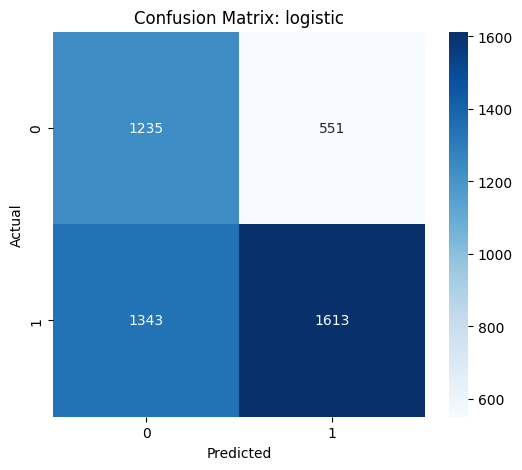


=== Training ridge ===
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'model__alpha': 0.13292918943162169}
Metrics: {'accuracy': 0.6488823281315901, 'balanced_accuracy': 0.5731005096018196, 'log_loss': 12.65556366361874, 'roc_auc': 0.5731005096018196, 'f1_weighted': 0.609092972474779}


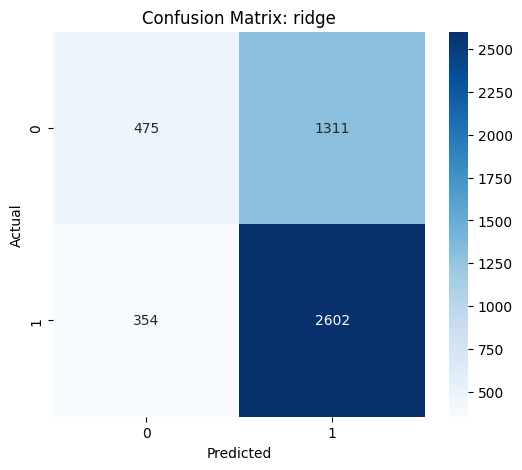


=== Training sgd ===
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'model__alpha': 0.0027541439213320295, 'model__loss': 'modified_huber', 'model__penalty': 'elasticnet'}
Metrics: {'accuracy': 0.6442429354702657, 'balanced_accuracy': 0.5687144184129457, 'log_loss': 0.720043701475328, 'roc_auc': 0.6694622094565005, 'f1_weighted': 0.6046302523934798}


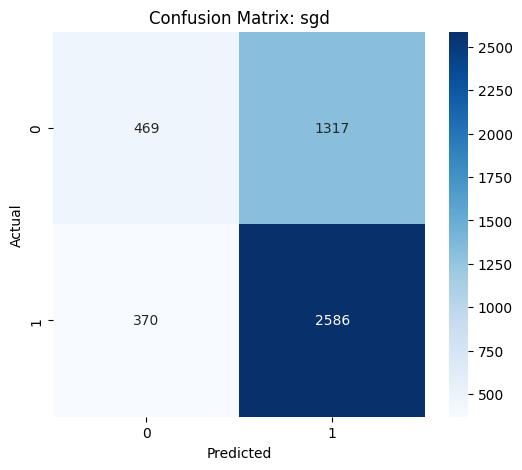


=== Training svm_rbf ===
Fitting 5 folds for each of 20 candidates, totalling 100 fits


KeyboardInterrupt: 

In [24]:
# train all models
# model_dict={'sgd': models['sgd'], 'logistic': models['logistic']}
results = train_and_evaluate(X_train, y_train_enc, X_test, y_test_enc, models)


In [ ]:
y_train_enc

array([1, 1, 1, ..., 1, 1, 1])

In [17]:
# Top 3 models by ROC AUC
top_models = summary_df.sort_values(by='ROC AUC', ascending=False).head(3)
print(top_models)


           Model  Accuracy  Balanced Accuracy  Log Loss   ROC AUC  F1 Weighted
6       svm_poly  0.843555           0.782152  0.347566  0.935105     0.845985
5        svm_rbf  0.841996           0.768233  0.356540  0.934509     0.844082
4  logistic_saga  0.870062           0.757526  0.354306  0.934403     0.863523


In [32]:
top_models

,Model,Accuracy,Balanced Accuracy,Log Loss,ROC AUC,F1 Weighted
6,svm_poly,0.843555,0.782152,0.347566,0.935105,0.845985
5,svm_rbf,0.841996,0.768233,0.356540,0.934509,0.844082
4,logistic_saga,0.870062,0.757526,0.354306,0.934403,0.863523
